# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random

import gym
from gym import spaces, Env
from gym.spaces import Box, Discrete
import matplotlib.pyplot as plt

from sac_networks import Actor, Critic, ValueNetwork, SACAgent, rescale_action, rescale_array
from collections import deque
from expt_utils import get_latest_folder

from buffer import ReplayBuffer, HERReplayBuffer
import threading
import time
import os

In [ ]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

from Manipulation_env  import Manipulation_multi_object as Manipulation
#from buffer_functions import save_buffer, load_buffer, append_buffer
from model_buffer_saving_functions import save_replay_buffer, load_replay_buffer, save_sac_agent, load_sac_agent, save_dict_to_h5, load_h5_to_dict


In [3]:
import time
import threading
import sys, time, os, threading
from PyQt5 import QtCore, QtWidgets, QtGui
from PyQt5.QtCore import Qt
import random
import string

# Functions


In [4]:
def initialize_env_agent(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_transitions = 1,continue_to_complete = False, drift_comp = True, reward_tolerance = 0.15,
                         margin = 0, label_margin = 0, target_control = None, nearest_coords_dim =6, st_offset = None, end_offset = None, use_env_reward_fn = True, 
                         param_model_path = None, offset_model_path = None, replay_buffer_path = None, her_buffer_path = None):

    
    env = Manipulation(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_transitions = n_transitions, continue_to_complete = continue_to_complete, 
                   drift_comp = drift_comp, reward_tolerance= reward_tolerance, anchor = (False, 0, False), margin = margin, label_margin = label_margin, target_control = target_control, 
                   st_offset = st_offset, end_offset = end_offset)

    state_dim = env.observation_space.shape[0]
    param_action_dim = env.action_space["param"].shape[0]
    position_action_dim = env.action_space["offset"].shape[0]
    goal_dim = env.target.shape[1]
    
    param_agent = SACAgent(state_dim, param_action_dim, gcrl = False, a_lr = 1e-4, c_lr = 3e-4, tau =0.005, goal_dim=0)
    position_agent = SACAgent(state_dim + nearest_coords_dim, position_action_dim, gcrl = True, a_lr = 1e-4, c_lr = 3e-4, tau =0.005, goal_dim=goal_dim)

    buffer = ReplayBuffer()
    her_buffer = HERReplayBuffer(k_future=int(0.4*n_transitions), env = env, use_env_reward_fn=use_env_reward_fn) 
    
    if replay_buffer_path is not None:
        buffer.buffer = load_replay_buffer(buffer, filename=replay_buffer_path)
    if her_buffer_path is not None:
        her_buffer.buffer = load_replay_buffer(her_buffer, filename=her_buffer_path)

    buffer_dict = {'replay_buffer': buffer, 'her_buffer': her_buffer}

    if param_model_path is not None:
        param_agent = load_sac_agent(param_agent, filename=param_model_path)
    if offset_model_path is not None:
        position_agent = load_sac_agent(position_agent, filename=offset_model_path)
    agent_dict = {'param_agent': param_agent, 'offset_agent': position_agent}
    

    return env, agent_dict, buffer_dict

In [5]:

def train_model(env, agent_dict, buffer_dict, n_episodes, transitions_per_episode, batch_size, train_start = 256, updates_per_step = 1,
                epsilon = 0.0, stop_event = None, result_container = None, 
                info_callback=None, expt_log_dir = 'model2', get_func_attrs = None):
    
    param_agent = agent_dict['param_agent']
    position_agent = agent_dict['offset_agent']

    buffer = buffer_dict['replay_buffer']
    her_buffer = buffer_dict['her_buffer']


    episode_data = {'ep_rewards': [], 'ep_length': []}
    param_training_data = {'actor_loss': [], 'critic_loss': [], 'td_error':[]}
    position_training_data = {'actor_loss': [], 'critic_loss': [], 'td_error':[]}
   
    combine_training_data = lambda d1, d2: {'param': d1, 'offset': d2}
    
    iter_rewards = []


    


    for ep in range(n_episodes):

        obs = env.reset()[0]
        state = obs['observation']
        achieved = obs['achieved_goal']
        goal = obs['desired_goal']   
        state1 = obs['state_with_near_coords'] # state with 3 nearest-neighbor coords


        episode_reward = 0
        
        episode_transitions = []


        for t in range(transitions_per_episode):

            # Update training hyperparameters
            func_attrs = None
            if get_func_attrs is not None:
                func_attrs = get_func_attrs()
                updates_per_step = func_attrs.get('updates_per_step', updates_per_step) if func_attrs is not None else updates_per_step
                epsilon = func_attrs.get('epsilon', epsilon) if func_attrs is not None else epsilon
                func_attrs = {"updates_per_step": updates_per_step, "epsilon": epsilon}



            if stop_event is not None and stop_event.is_set():
                
                print("Training stopped.")
                if result_container is not None:
                    result_container['training_data'] = combine_training_data(param_training_data, position_training_data)
                    result_container['iter_rewards'] = iter_rewards
                return 
            
            if env._finished:
                print("Target reached, Ending training.")
                result_container['training_data'] = combine_training_data(param_training_data, position_training_data)
                result_container['iter_rewards'] = iter_rewards
                return
            
        
            state_initial = state
            with torch.no_grad():
                param_action = param_agent.select_action(state, epsilon = epsilon)
                position_action = position_agent.select_action(state1, epsilon = epsilon, goal = goal)


            print(f"Param action: {param_action}, Position action: {position_action}")

            action_dict = {'param': np.ravel(param_action),
                           'offset': np.ravel(position_action)}
            
            next_obs, reward, done, truncation, info = env.step(action_dict)
            next_state = next_obs['observation']
            achieved = next_obs['achieved_goal']
            goal = next_obs['desired_goal']
            next_state1 = next_obs['state_with_near_coords']
            iter_rewards.append(reward)
            

            info_callback(info, func_attrs) if info_callback is not None else None
            result_container['iter_rewards'] = iter_rewards if result_container is not None else None

            
            buffer.push(state, param_action, reward, next_state, done)

            # Store transition for HER buffer - uses the state with nearest neighbor coords
            transition = (state1, position_action, reward, next_state1, goal, achieved, done)
            episode_transitions.append(transition)


            state = next_state
            state1 = next_state1
            episode_reward += reward

            # Traning in on-policy mode. This can be updated at every step or after every episode.
            if len(buffer) > train_start and ep > 0:
                for _ in range(updates_per_step):
                    param_training_log = param_agent.update(buffer, batch_size)
                    position_training_log = position_agent.update_cql(her_buffer, batch_size)

                    
                    param_training_data['actor_loss'].append(param_training_log['actor_loss'])
                    param_training_data['critic_loss'].append(param_training_log['critic_loss'])
                    param_training_data['td_error'].append(param_training_log['td_error'])

                    
                    position_training_data['actor_loss'].append(position_training_log['actor_loss'])
                    position_training_data['critic_loss'].append(position_training_log['critic_loss'])
                    position_training_data['td_error'].append(position_training_log['td_error'])

                    
                training_data = combine_training_data(param_training_data, position_training_data)                
                result_container['training_data'] = training_data if result_container is not None else None


            if done: # Early termination of the episode if target reached.
                break


        episode_data['ep_rewards'].append(episode_reward)
        episode_data['ep_length'].append(t+1)



        # Add episode transitions to HER buffer
        her_buffer.store_episode(episode_transitions)
        buffer_dict = {'replay_buffer': buffer, 'her_buffer': her_buffer}
        result_container['buffer'] = buffer_dict if result_container is not None else None


        # Save buffers and update models
        
        save_replay_buffer(buffer.buffer, filename=os.path.join(expt_log_dir, 'replay_buffer.h5'))
        save_replay_buffer(her_buffer.buffer, filename=os.path.join(expt_log_dir, 'her_buffer.h5'))
        save_sac_agent(param_agent, filename=os.path.join(expt_log_dir, 'param_agent.pth'))
        save_sac_agent(position_agent, filename= os.path.join(expt_log_dir, 'offset_agent.pth'))    
                
        training_data = combine_training_data(param_training_data, position_training_data)
        result_container['training_data'] = training_data if result_container is not None else None
        save_dict_to_h5(training_data, filename= os.path.join(expt_log_dir, 'training_data.h5'))

        
        # Store training data

        if len(buffer) > train_start:

            if ep % 1 == 0:
                print(f"Episode {ep}, Average Reward: {episode_reward:.2f}, Actor Loss: {position_training_log['actor_loss']:.4f}, Critic Loss: {position_training_log['critic_loss']:.4f}")
                print(f"State: {state_initial}, Action: {action_dict}, Next State: {next_state}, Reward: {reward}, Done: {done}")
                

    
    return training_data, buffer_dict, agent_dict



def info_callback(self, info, func_attrs= None):
    result = info.get('results', None)
    prev_result = info.get('prev_results', None)
    current_iter_results = info.get('current_iter_results', None)
    
    current_iteration = current_iter_results.get('iteration', None) if current_iter_results else None

    print("Current Iteration:", current_iteration )


In [6]:
def save_settings(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_episodes, 
         n_transitions, continue_to_complete, drift_comp, batch_size, train_start, updates_per_step, epsilon, reward_tolerance,
        margin, label_margin,
         target_control, st_offset, end_offset, use_env_reward_fn, param_model_path, 
         offset_model_path, replay_buffer_path, her_buffer_path, expt_log_dir, notes):
  settings = {
    'param_range': param_range.tolist(),
    'default_action_params': default_action_params.tolist(),
    'expt_name': expt_name,
    'sxm_basename': sxm_basename,
    'expt_dir': expt_dir,
    'n_episodes': n_episodes,
    'n_transitions': n_transitions,
    'continue_to_complete': continue_to_complete,
    'drift_comp': drift_comp,
    'batch_size': batch_size,
    'train_start': train_start,
    'updates_per_step': updates_per_step,
    'epsilon':epsilon,
    'reward_tolerance': reward_tolerance,
    'margin':margin,
    'label_margin':label_margin,
    'target_control': target_control,
    'st_offset': st_offset,
    'end_offset': end_offset,
    'use_env_reward_fn': use_env_reward_fn,
    'param_model_path': param_model_path,
    'offset_model_path': offset_model_path,
    'replay_buffer_path': replay_buffer_path,
    'her_buffer_path': her_buffer_path,
    'notes': notes
  }
  if not os.path.exists(expt_log_dir):
      os.makedirs(expt_log_dir)
  settings_path = os.path.join(expt_log_dir, 'settings.txt')
  with open(settings_path, 'w') as f:
    for key, value in settings.items():
      f.write(f"{key}: {value}\n")
  print(f"Settings saved to {settings_path}")

# Training

In [7]:
bias_range = [0.015, 0.020]   # (V)
setpoint_range = [80, 90]   # (nA)
speed_range = [0.5, 5]     #(nm/s)

#Default parameters (V, nA, nm/s):
bias = 0.08
setpoint = 1
speed = 5

expt_name = 'RL20_random_wa_dcons3nm'

sxm_basename = 'CO_on_Cu_'

expt_dir = r"E:\Ganesh\Manipulation_expts\routine8"

expt_log_dir = os.path.join(expt_dir, 'expt_log', expt_name)

n_episodes =  2000
n_transitions = 10
drift_comp = False
batch_size = 64
train_start = 1024
updates_per_step = 1
continue_to_complete = False
epsilon = 1
margin = 0.15
label_margin = 0.01

reward_tolerance = 0.20 # in nm.

target_control =   {
                    "target_type": "random_with_anchor",  
                    "anchor": {"condition": True, "anchor_idx":0, "anchor_point":[0.5, 0.5]},
                    "dmin_anchor_target":0.1,
                    "d_constant_anchor": 0.3,
                    "drift_comp":"trigger_on_anchor"
                   }


st_offset = {"type": "start_offset", "delta_offset":0}
end_offset = None




param_range = np.array([bias_range, setpoint_range, speed_range])
default_action_params = np.array([bias, setpoint, speed])
use_env_reward_fn = True

param_model_path = 'rl_models\rl_models\param\rescaled2_training22_a_lr1e-4_weight_decay1e-6\sac_agent_cql_10000.pth'
offset_model_path = 'rl_models\rl_models\offset\sac_agent_cql_100000.pth'
replay_buffer_path = "C:\Users\Administrator\Py_Scripts_ganesh\manipulation_scripts_3\buffers\combined_buffer\set1\rescaled2_combined_replay_buffer.h5"
her_buffer_path = "C:\Users\Administrator\Py_Scripts_ganesh\manipulation_scripts_3\buffers\combined_buffer\set1\combined_her_buffer.h5"


update_from_previous = False
latest_folder = get_latest_folder(os.path.join(expt_dir, 'expt_log'))
if latest_folder is not None and update_from_previous:
    print("Loading models and buffers from latest folder:", latest_folder)
    latest_folder = os.path.join(expt_dir, 'expt_log', latest_folder)
    param_model_path = os.path.join(latest_folder, 'param_agent.pth')
    offset_model_path = os.path.join(latest_folder, 'offset_agent.pth')
    replay_buffer_path = os.path.join(latest_folder, 'replay_buffer.h5')
    her_buffer_path = os.path.join(latest_folder, 'her_buffer.h5')

notes = "using yolo model 40, conf 0.1 iou 0.05"

#save settings
save_settings(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_episodes, 
       n_transitions, continue_to_complete, drift_comp, batch_size, train_start, updates_per_step, epsilon, reward_tolerance,
        margin, label_margin,target_control, st_offset, end_offset, use_env_reward_fn, param_model_path, 
       offset_model_path, replay_buffer_path, her_buffer_path, expt_log_dir, notes)

training_fn_attrs = {'updates_per_step': updates_per_step, 'epsilon': epsilon}

Settings saved to E:\Ganesh\Manipulation_expts\routine8\expt_log\RL20_random_wa_dcons3nm\settings.txt


sxm_file_name: CO_on_Cu_2977.sxm


C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



image 1/1 E:\Ganesh\Manipulation_expts\routine8\images\CO_on_Cu_2977.jpg: 256x256 4 COs, 95.6ms
Speed: 1.0ms preprocess, 95.6ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs\detect\predict2694
1 label saved to runs\detect\predict2694\labels
label path is here: runs\detect\predict2694\labels\CO_on_Cu_2977.txt
sxm_file_name: CO_on_Cu_2977.sxm


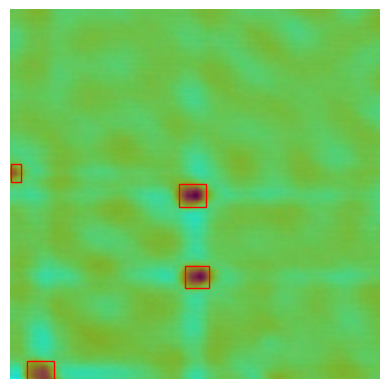

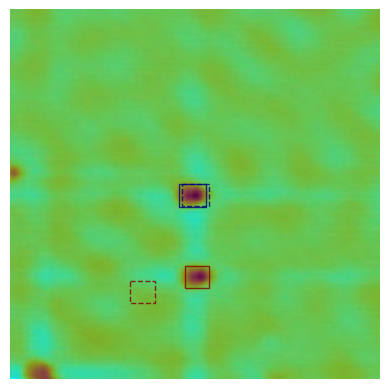

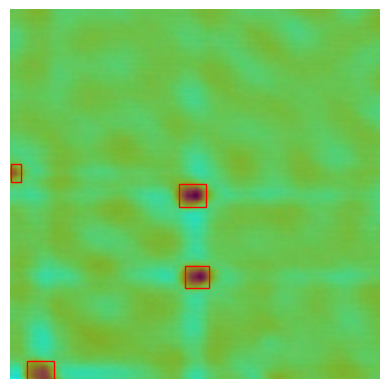

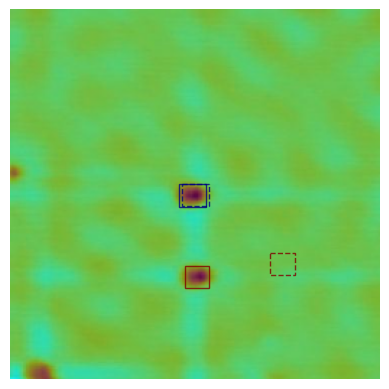

In [8]:
env, agent_dict, buffer_dict = initialize_env_agent(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_transitions,
                                                    continue_to_complete= continue_to_complete, drift_comp=drift_comp, reward_tolerance=reward_tolerance,
                                                    margin = margin, label_margin = label_margin,
                                                    target_control=target_control, nearest_coords_dim=7, st_offset = st_offset, end_offset=end_offset, use_env_reward_fn = use_env_reward_fn,
                                                    param_model_path=param_model_path, 
                                                    offset_model_path = offset_model_path, replay_buffer_path= replay_buffer_path, her_buffer_path=her_buffer_path)

# Interface

Iteration:   488
Action params: Bias = 0.016 V,	Setpoint = 88.44 nA,	speed = 4.93 nm/s
Reward: 7.1402203744419594, 	norm_displacement: -0.01722506082640829


Current iteration:   489
start new session:  False
Action params: Bias = 0.016 V,	Setpoint = 88.34 nA,	speed = 4.92 nm/s 

Molecule index: 1
Action::  {'param': array([     -0.628,     0.66875,     0.96441], dtype=float32), 'offset': array([     0.5978,     0.80055], dtype=float32)}
Rescaled_action:  [    0.01593      88.344      4.9199]
Drift compensation: True, Anchor placed:True
offset_action: [     0.5978     0.80055], target_difference: ([    0.05978    0.080055]
Stuck: False, stuck_count:0
d_space_prev 0.9025288990237398
Initial_coords:[-2.3971e-07  1.1362e-06]	Final_coords: [-2.3703e-07  1.1448e-06],	 drift: [   0.004873    0.007926],	 Angle: 43.94620594058323
default_params: [       0.08           1           5]

#####	Manipulation in progress....	#####
	Moving to initial position
	Updating manipulation parameters
	Moving 

Exception in thread Thread-6 (train_model):
Traceback (most recent call last):
  File "C:\Program Files\Python310\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "C:\Program Files\Python310\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Administrator\AppData\Local\Temp\ipykernel_24520\3236886370.py", line 76, in train_model
  File "C:\Users\Administrator\Py_Scripts_ganesh\manipulation_scripts_3\Manipulation_env_1.py", line 242, in step
    self.X_current, X_target, self.state_params, self.corrected_states, self.norm_drift, self.avg_label_width, self.labels, self.filename = get_state_MO(self.basename, self.expt_dir, self.X_target, self.iteration_count, self.obj_idx, label_margin=self.label_margin, anchor_tuple=(self.anchor_placed, self.anchor_idx))
  File 

SystemExit: 0

C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


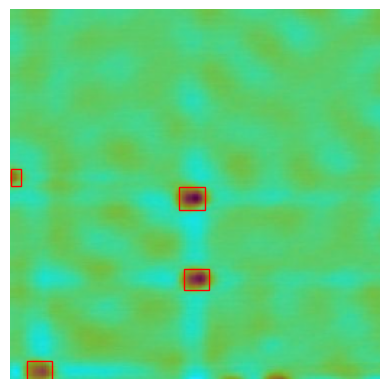

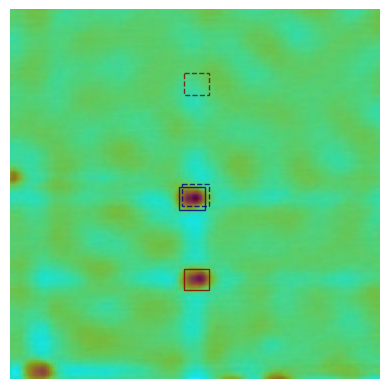

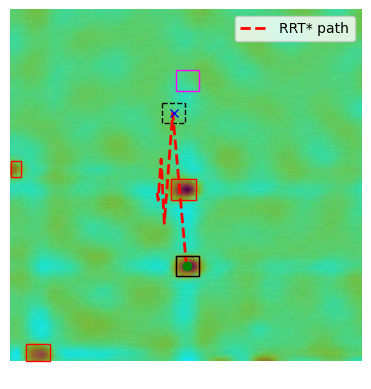

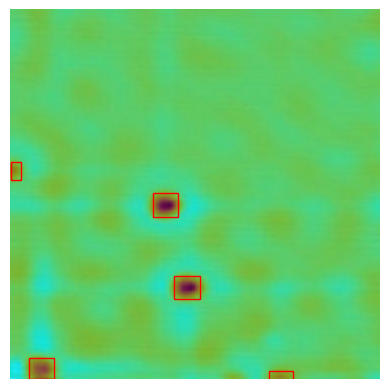

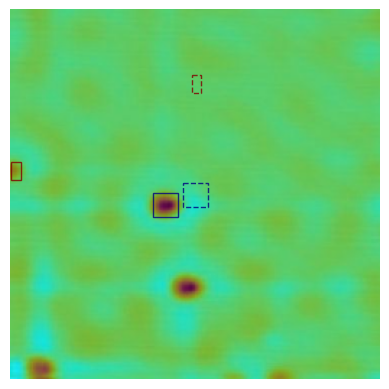

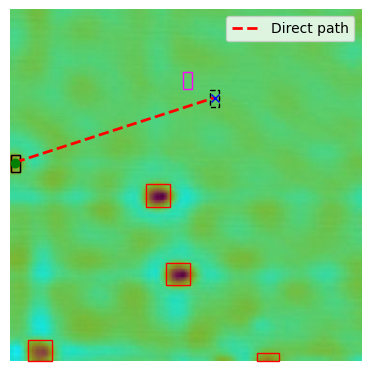

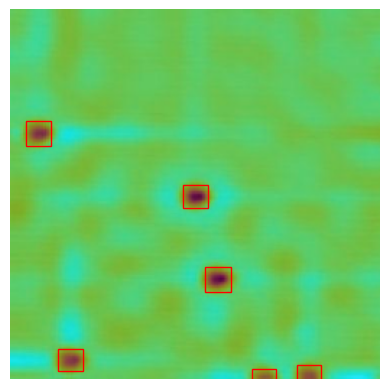

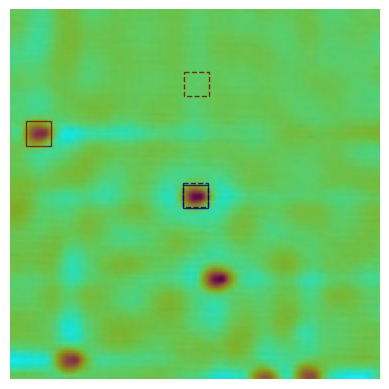

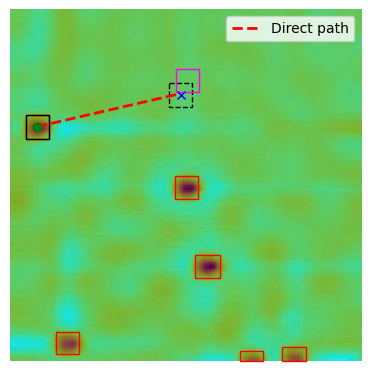

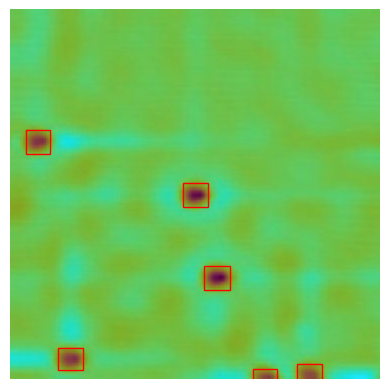

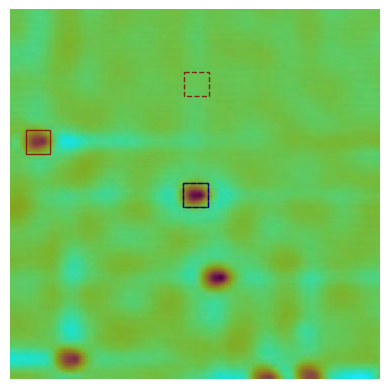

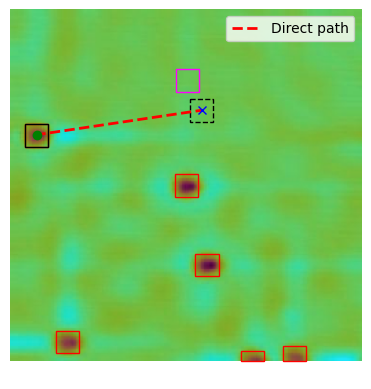

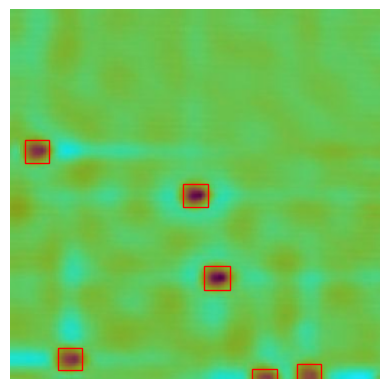

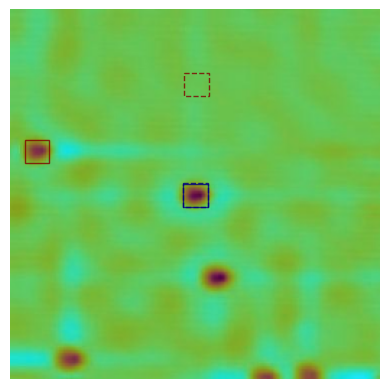

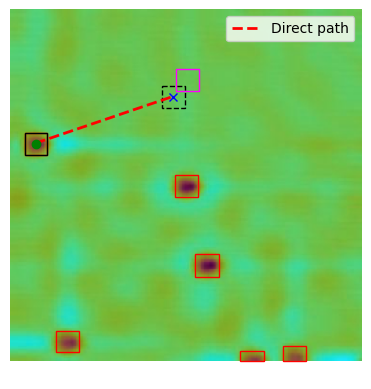

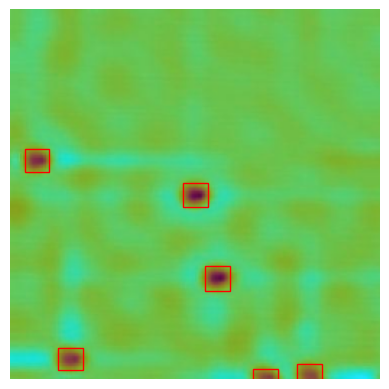

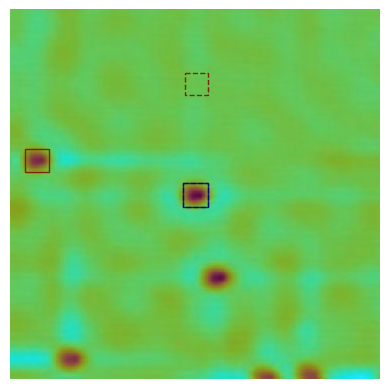

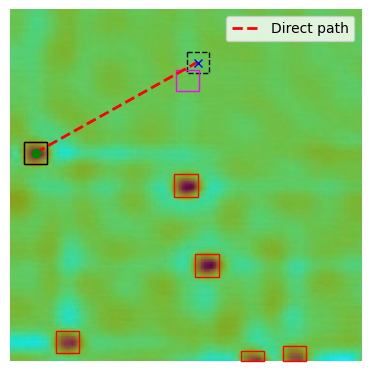

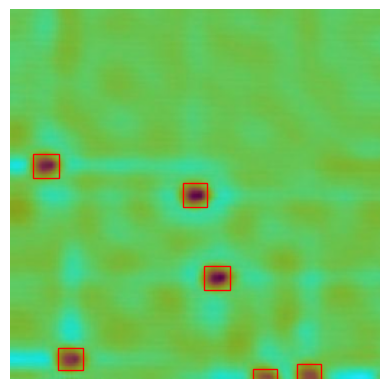

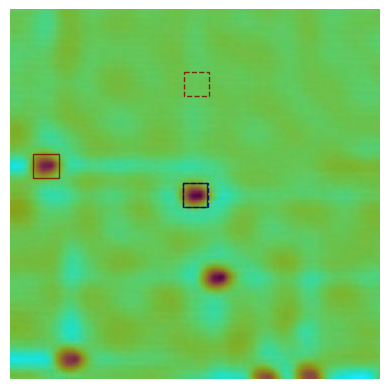

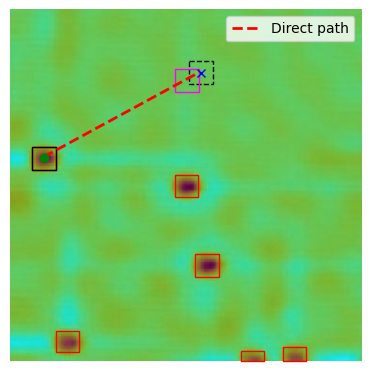

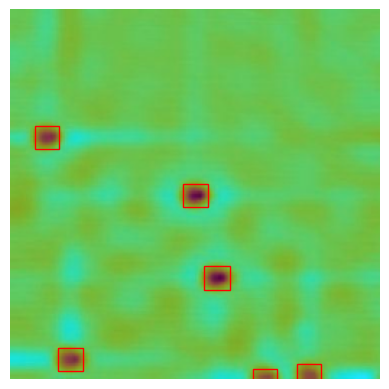

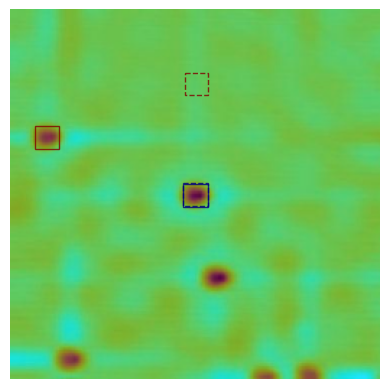

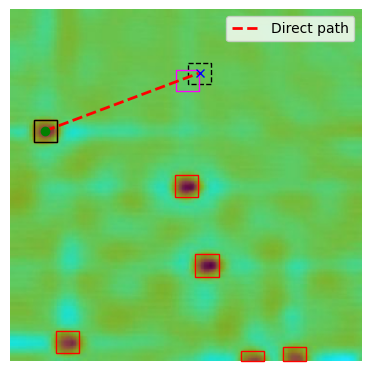

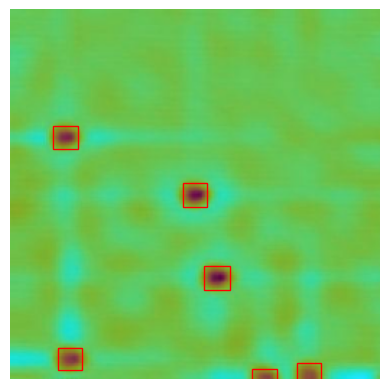

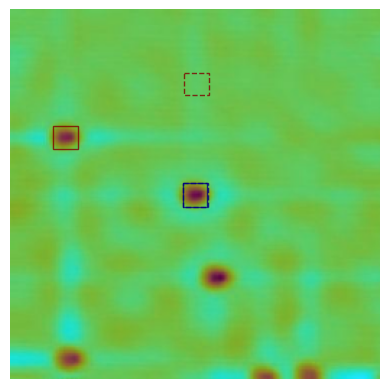

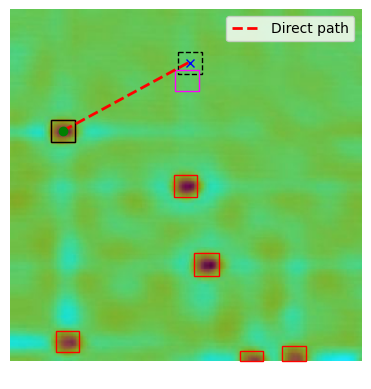

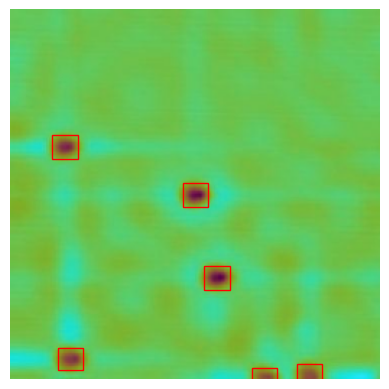

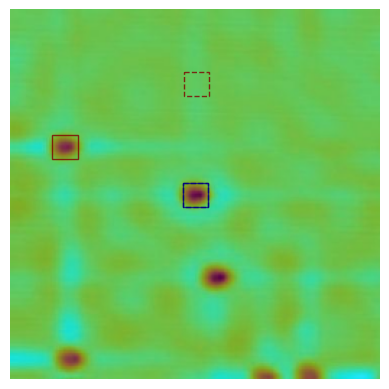

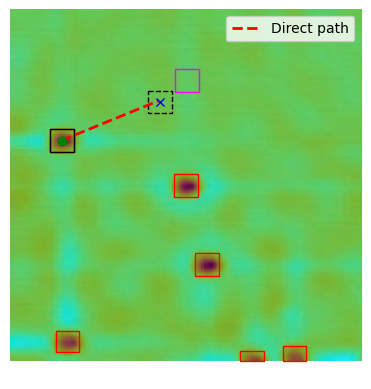

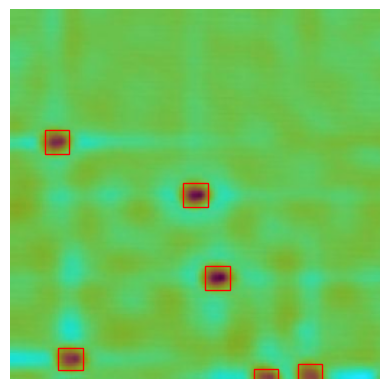

Error in callback <function flush_figures at 0x0000010E8B8FF250> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [11]:
from gui.gui import Manipulation_GUI

def main():
    import sys
    app = QtWidgets.QApplication(sys.argv)
    win = Manipulation_GUI(train_model, env, agent_dict, buffer_dict, n_episodes, n_transitions, batch_size, train_start, updates_per_step, epsilon, training_fn_attrs)
    win.show()
    sys.exit(app.exec_())


if __name__ == "__main__":
    main()